Remember to launch this from a directory where the environment has been correctly configured

In [1]:
import omnidsp_py
import numpy as np
import librosa
from matplotlib import pyplot as plt

In [2]:
# Example using rfft (double precision)
N = 8192
freq = 20.0
signal = np.cos(2.0 * np.pi * freq * np.arange(N) / N).astype(np.float64)

# Use the bound convenience function
spectrum = omnidsp_py.rfft(signal)

print(f"Input signal shape: {signal.shape}")
print(f"Output spectrum shape: {spectrum.shape}") # Should be N/2 + 1
print("Spectrum from omnidsp_py (first 5 bins):")
print(spectrum[:5])

np_spec = np.fft.rfft(signal)
print("Spectrum from numpy (first 5 bins):")
print(np_spec[:5])

Input signal shape: (8192,)
Output spectrum shape: (4097,)
Spectrum from omnidsp_py (first 5 bins):
[-3.10994150e-13+0.00000000e+00j -3.14794160e-13+4.17703934e-15j
 -3.11645786e-13-1.57695848e-15j -3.16128475e-13+2.15437189e-14j
 -3.99223527e-13-3.83247741e-14j]
Spectrum from numpy (first 5 bins):
[-3.10994150e-13+0.00000000e+00j -3.14794160e-13+4.17703934e-15j
 -3.11645786e-13-1.57695848e-15j -3.16128475e-13+2.15437189e-14j
 -3.99223527e-13-3.83247741e-14j]


In [ ]:
sample_rate = 44100.0
fmin = 15.0
fmax = 1000.0
bins_per_octave = 12

# --- Define the window function callable ---
# This lambda takes the dummy array passed from C++, determines the
# required length, creates a placeholder array of ones, applies the C++
# bound Hann window to it, and returns the resulting coefficients.
hann_generator = lambda dummy_arr: omnidsp_py.Window.hann(
    np.ones(len(dummy_arr), dtype=dummy_arr.dtype)
)

# --- Use the factory function ---
try:
    cqt_plan = omnidsp_py.create_cqt_plan(
        sample_rate=sample_rate,
        lowest_freq=fmin,
        highest_freq=fmax,
        bins_per_octave=bins_per_octave,
        window_function=hann_generator, # Pass the Python lambda
        precision=omnidsp_py.Precision.DOUBLE # Specify precision
    )

    # Execute the plan (assuming 'signal' is defined and is float64)
    if 'signal' in locals() and signal.dtype == np.float64:
        omnidsp_cqt_complex = cqt_plan.execute(signal)
        omnidsp_cqt_amp = np.abs(omnidsp_cqt_complex)
        print(f"CQT Output shape: {omnidsp_cqt_amp.shape}")
        # print(f"First 5 CQT amplitudes: {omnidsp_cqt_amp[:5]}")
    else:
        print("Please define 'signal' as a float64 NumPy array before executing.")

except Exception as e:
    print(f"An error occurred: {e}")

CQT Output shape: (73,)


In [6]:
librosa_cqt_amp = np.abs(librosa.cqt(
    signal,
    sr=sample_rate,
    fmin = fmin,
    window='hann',
)).flatten()

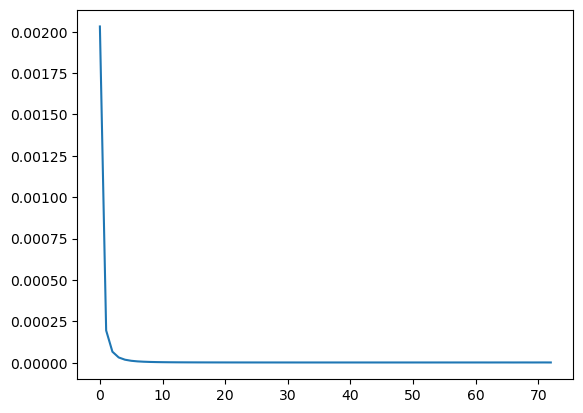

In [7]:
plt.plot(omnidsp_cqt_amp)

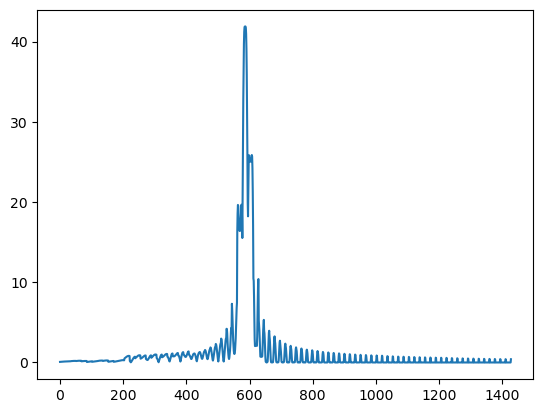

In [8]:
plt.plot(librosa_cqt_amp)